# Procesamiento de Datos con APIs - SpaceX API

# 0. Setup

In [2]:
%pip install pandas matplotlib seaborn requests

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import numpy as np

# Path permite construir rutas de archivos de forma más robusta que concatenar strings.
from pathlib import Path

# asyncio es una librería para programación asíncrona en Python,
# sleep es una función que permite pausar la ejecución de un programa durante un tiempo determinado.
from asyncio import sleep

# Controla cuantas columnas se muestran (pandas)
pd.set_option('display.max_columns', 50)

# Controla el ancho de impresion en consola del notebook
pd.set_option('display.width', 200)

# Limita el largo de strings en cada celda mostrada (para facilitar lectura)
pd.set_option('display.max_colwidth', 80)

# Aplica un estilo visual global de seaborn a los gráficos. whitegrid es un estilo con cuadricula y fondo blanco
# palette='deep' es una paleta de colores predefinida de seaborn que se aplica a los gráficos para mejorar su apariencia visual
sns.set_theme(style="whitegrid", palette='deep')

# Define el tamaño por defecto de los gráficos generados con matplotlib.
# Esto afecta a todos los gráficos que se creen después de esta línea,
# a menos que se especifique un tamaño diferente para un gráfico específico.
plt.rcParams['figure.figsize'] = (10, 6)


BASE_URL = 'https://api.spacexdata.com/v4'


CACHE_DIR = Path('data/spacex_cache')


# Funcion para contruir la ruta del archivo cache de un endpoint
def cache_path(endpoint: str) -> Path:
    # Ejemplo: endpoint = 'launches' -> data/spacex_cache/launches.json
    return CACHE_DIR / f"{endpoint}.json"

# Funcion para cargar datos de un endpoint desde el cache local
def load_cache(endpoint: str):
    # .open() es un metodo de Path que abre el archivo en modo lectura y devuelve un objeto file-like
    # encoding='utf-8' asegura que el archivo se lea con la codificacion correcta, especialmente si contiene caracteres especiales
    with cache_path(endpoint).open(encoding='utf-8') as f:
        # json.load() lee el contenido del archivo JSON y lo convierte en un objeto de Python
        return json.load(f)


# Funcion para guardar datos de un endpoint/api en el cache local
def save_cache(endpoint: str, data) -> None:

    # mkdir(parents=True, exist_ok=True) crea el directorio cache si no existe.
    # parents=True permite crear cualquier directorio padre necesario, exist_ok=True evita errores si el directorio ya existe.
    CACHE_DIR.mkdir(parents=True, exist_ok=True)  # Crea el directorio cache si no existe

    # Abrimos en modo escritura ('w') y en utf-8 para guardar el JSON con la codificación correcta
    with cache_path(endpoint).open('w', encoding='utf-8') as f:

        # ensure_ascii=False permite que los caracteres no ASCII se guarden correctamente en el archivo JSON,
        # en lugar de ser escapados como secuencias Unicode.
        # ident=2 hace que el JSON se guarde con una indentación de 2 espacios, lo que mejora la legibilidad del archivo.
        json.dump(data, f, ensure_ascii=False, indent=2)



print("Setup listo, ya podemos empezar a trabajar con los datos de SpaceX!")        



Setup listo, ya podemos empezar a trabajar con los datos de SpaceX!


# 1. Ingesta desde la API

### 1.1 Inspección manual de UN lanzamiento

In [4]:

# Intentamos obtener los datos del ultimo lanzamiento de SpaceX desde la API
try:
    # requests.get() hace una solicitud HTTP GET a la URL especificada
    # y devuelve un objeto Response que contiene la respuesta del servidor.
    response = requests.get(f'{BASE_URL}/launches/latest', timeout=10)

    # Lanza un error si la respuesta no es exitosa (status code 4xx o 5xx)
    response.raise_for_status()  

    # Convierte la respuesta JSON en un diccionario de Python
    sample = response.json() 

    # Guardamos el resultado en cache para futuras referencias
    save_cache('latest_launch', sample)  

except requests.RequestException as e:

    print(f"API no disponible: ({e}). Cargando datos del cache local...")    
    # Carga los datos del cache local si la API no está disponible
    sample = load_cache('latest_launch') 

#Recorremos cada clave-valor del diccionario sample e imprimimos su contenido de forma legible
for key, value in sample.items():

    # Obtiene el tipo de dato del valor
    tipo = type(value).__name__  
    # Obtiene una vista previa de los primeros 60 caracteres del valor
    preview = str(value)[:60]  

    # :25 alinea la clave en 25 caracteres, | es un separador visual, :10 alinea el tipo en 10 caracteres
    # y luego se muestra la vista previa
    # Imprime la clave, el tipo de dato y la vista previa en un formato tabla
    print(f'{key:25} | {tipo:10} | {preview}')


fairings                  | NoneType   | None
links                     | dict       | {'patch': {'small': 'https://images2.imgbox.com/eb/d8/D1Yywp
static_fire_date_utc      | NoneType   | None
static_fire_date_unix     | NoneType   | None
net                       | bool       | False
window                    | NoneType   | None
rocket                    | str        | 5e9d0d95eda69973a809d1ec
success                   | bool       | True
failures                  | list       | []
details                   | NoneType   | None
crew                      | list       | ['62dd7196202306255024d13c', '62dd71c9202306255024d13d', '62
ships                     | list       | []
capsules                  | list       | ['617c05591bad2c661a6e2909']
payloads                  | list       | ['62dd73ed202306255024d145']
launchpad                 | str        | 5e9e4502f509094188566f88
flight_number             | int        | 187
name                      | str        | Crew-5
date_utc            

### 1.2 Función de ingesta robusta (reutilizable)

In [5]:
# Definimos una funcion reutilizable para descargar endpoints de la API
# endpoint: el nombre del endpoint a descargar (ejemplo: 'launches', 'rockets', etc.)
# max_retries: el numero maximo de intentos para descargar el endpoint antes de rendirse
# backoff: el factor de aumento del tiempo de espera entre reintentos
# (ejemplo: 1.5 significa que el tiempo de espera se multiplicará por 1.5 después de cada intento fallido)

def fetch_endpoint(endpoint: str, max_retries: int = 3, backoff: float = 1.5) -> list:

    # Construimos la URL completa del endpoint a descargar
    url = f'{BASE_URL}/{endpoint}'
    # 
    last_error = None

    for attempt in range(max_retries):
        try:

            r = requests.get(url, timeout=15)

            r.raise_for_status()  # Lanza un error si la respuesta no es exitosa (status code 4xx o 5xx)

            data = r.json()  # Convierte la respuesta JSON en un objeto de Python (lista o diccionario)

            save_cache(endpoint, data)  # Guarda los datos descargados en el cache local

            return data
        except requests.RequestException as e:
            # guardamos el error para reportarlo si se agotan los intentos
            last_error = e

            # backoff **attempt produce esperas 1.0, .5, 2.25, etc. dependiendo del numero de intento
            wait = backoff * attempt

            # Mostramos un mensaje de error con el numero de intento, el error ocurrido y el tiempo de espera antes del siguiente intento
            print(f' [intento {attempt+1}] Error: {e}. Reintentando en {wait:.1f} segundos...')

            # Pausamos la ejecución del programa durante el tiempo de espera calculado antes de intentar nuevamente
            sleep(wait)

    # Si agotan los intentos, probamos la cache local
    try:

        print(f"Agotados los intentos para descargar {endpoint} desde la API. Cargando datos del cache local...")
        #Devolviendo el json guardado en disco
        return load_cache(endpoint)  # Carga los datos del cache local si la API no está disponible 
    
    #Si tampoco hay cache local, reportamos el error final al usuario
    except FileNotFoundError:
        raise RuntimeError(
            f"No se pudo descargar los datos de {endpoint} desde la API ni cargar el cache local. Tras {max_retries} intentos."
            ) from last_error
    

print("Descargando datos de SpaceX...\n")

# Descargamos los datos de lanzamientos utilizando la función fetch_endpoint, que maneja reintentos y cache local
print("Descargando lanzamientos...")
launches_raw = fetch_endpoint('launches')
print(f'Se descargaron {len(launches_raw)} lanzamientos.\n')

# Descargamos los datos de cohetes utilizando la función fetch_endpoint, que maneja reintentos y cache local
print("Descargando rockets...")
rockets_raw = fetch_endpoint('rockets')
print(f'Se descargaron {len(rockets_raw)} cohetes.\n')

# Descargamos los datos de launchpads utilizando la función fetch_endpoint, que maneja reintentos y cache local
print("Descargando launchpads...")
launchpads_raw = fetch_endpoint('launchpads')
print(f'Se descargaron {len(launchpads_raw)} plataformas de lanzamiento.\n')

# Descargamos los datos de payloads utilizando la función fetch_endpoint, que maneja reintentos y cache local
print("Descargando payloads...")
payloads_raw = fetch_endpoint('payloads')
print(f'Se descargaron {len(payloads_raw)} payloads.\n')


Descargando datos de SpaceX...

Descargando lanzamientos...
Se descargaron 205 lanzamientos.

Descargando rockets...
Se descargaron 4 cohetes.

Descargando launchpads...
Se descargaron 6 plataformas de lanzamiento.

Descargando payloads...
Se descargaron 225 payloads.



### 1.3 De JSON a DataFrame

In [6]:

# Convertimos listas de diccionarios en DataFrames de pandas para facilitar su manipulación y análisis
# pd.json_normalize() es una función de pandas que convierte una lista de diccionarios anidados en un DataFrame plano.
# sep='_' define el separador usado al crear nombre de columnas anidadas
df_launches = pd.json_normalize(launches_raw, sep='_')

# repetimos el proceso para cada endpoint descargado
df_rockets = pd.json_normalize(rockets_raw, sep='_')
df_launchpads = pd.json_normalize(launchpads_raw, sep='_')
df_payloads = pd.json_normalize(payloads_raw, sep='_')


# shape muestra el numero de filas y columnas del DataFrame, asi como el tipo de dato de cada columna
print("Estructura de los datos descargados:")
print(f"Launches: {df_launches.shape} (filas, columnas)")
print(f"Rockets: {df_rockets.shape} (filas, columnas)")
print(f"Launchpads: {df_launchpads.shape} (filas, columnas)")
print(f"Payloads: {df_payloads.shape} (filas, columnas)")


Estructura de los datos descargados:
Launches: (205, 43) (filas, columnas)
Rockets: (4, 56) (filas, columnas)
Launchpads: (6, 15) (filas, columnas)
Payloads: (225, 34) (filas, columnas)


In [7]:
# Inspeccionamos los nombres de columnas generados por json_normalize
# Esto nos ayuda a entender la estructura de los datos y a identificar posibles columnas de interés para nuestro análisis.
print('Columnas en df_launches:')

# Recorremos cada columna del DataFrame df_launches e imprimimos su nombre
for col in df_launches.columns:
    # Imprime el nombre de la columna con un guion y un espacio al inicio para mejorar la legibilidad
    print(f'- {col}')


Columnas en df_launches:
- static_fire_date_utc
- static_fire_date_unix
- net
- window
- rocket
- success
- failures
- details
- crew
- ships
- capsules
- payloads
- launchpad
- flight_number
- name
- date_utc
- date_unix
- date_local
- date_precision
- upcoming
- cores
- auto_update
- tbd
- launch_library_id
- id
- fairings_reused
- fairings_recovery_attempt
- fairings_recovered
- fairings_ships
- links_patch_small
- links_patch_large
- links_reddit_campaign
- links_reddit_launch
- links_reddit_media
- links_reddit_recovery
- links_flickr_small
- links_flickr_original
- links_presskit
- links_webcast
- links_youtube_id
- links_article
- links_wikipedia
- fairings


El aplanamiento generó columnas separadas para cada clave anidada. Ej: links_youtube_id, links_...., etc

# 2. Exploración (EDA con intención)

Una EDA útil responde preguntas específicas:

1. **¿Cuántos registros hay y de qué período?**
2. **¿Qué columnas son realmente útiles vs relleno?**
3. **¿Dónde están los nulos y por qué están ahí? --- Esta es la más importante**
4. **¿Hay duplicados? ¿Cómo se definen?**

La EDA empieza con inventario, no con gráficas. Se empieza con preguntas sencillas.


### 2.1 Resumen estructural

In [8]:

print('Dimensiones y Tipos de datos en df_launches:')

print(df_launches.info())

Dimensiones y Tipos de datos en df_launches:
<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   static_fire_date_utc       121 non-null    str    
 1   static_fire_date_unix      121 non-null    float64
 2   net                        205 non-null    bool   
 3   window                     117 non-null    float64
 4   rocket                     205 non-null    str    
 5   success                    186 non-null    object 
 6   failures                   205 non-null    object 
 7   details                    134 non-null    str    
 8   crew                       205 non-null    object 
 9   ships                      205 non-null    object 
 10  capsules                   205 non-null    object 
 11  payloads                   205 non-null    object 
 12  launchpad                  205 non-null    str    
 13  flight_number   

Construir un tabla que muestre para cada columna:

* número de nulos  ---> df_launches.isna().sum() cuenta nulos por columna
* porcentaje de nulos ---> dividir por len(df_launches) y multiplicar por 100 
* tipo de dato ---> devolver los tipos con df_launches.dtypes
* número de valores únicos ---> nunique()

**No hacer fillna() automáticamente sin entender el significado del nulo**

### 2.2 Auditoría de nulos

In [9]:
# Definimos una función para contar valores distintos en una columna de forma segura, manejando posibles errores de tipo
def safe_nunique(col):
    try:
        # Contamos valores distintos ignorando nulos por defecto
        return col.nunique()

    except TypeError:
        # si la columna tiene listas o diccionarios, convertimos cada valor a string antes de contar los distintos
        return col.apply(str).nunique()
    
# Construimos una tabla de auditoría con una fila por columna orignal
nulos = pd.DataFrame({
    # cantidad de valores faltantes (nulos) en cada columna del DataFrame df_launches
    'nulos': df_launches.isna().sum(),

    # porcentaje de valores faltantes (nulos) respecto al total de filas en el DataFrame df_launches
    # multiplicamos por 100 para obtener el porcentaje y redondeamos a 2 decimales para mejorar la legibilidad
    'pct_nulos': (df_launches.isna().sum() / len(df_launches) * 100).round(2),

    # tipo de dato de cada columna convertido a string para mejor legibilidad
    'tipo': df_launches.dtypes.astype(str),    

    # cantidad de valores distintos en cada columna utilizando la función safe_nunique definida anteriormente
    'valores_distintos': df_launches.apply(safe_nunique)

}).sort_values('pct_nulos', ascending=False)  # Ordenamos la tabla de auditoría por porcentaje de nulos de mayor a menor

print(' Columnas con mayor porcentaje de nulos en df_launches:')
print(nulos.head(15))

#linea en blanco
print()

print('Columnas sin nulos en df_launches:')
print(nulos[nulos['nulos'] == 0].head(15))

#linea en blanco
print()




 Columnas con mayor porcentaje de nulos en df_launches:
                           nulos  pct_nulos     tipo  valores_distintos
fairings                     205     100.00  float64                  0
launch_library_id            133      64.88      str                 72
fairings_recovered           120      58.54   object                  2
links_reddit_media           117      57.07      str                 87
links_presskit               114      55.61      str                 91
fairings_reused              112      54.63   object                  2
links_reddit_recovery        110      53.66      str                 40
fairings_recovery_attempt     98      47.80   object                  2
window                        88      42.93  float64                 25
static_fire_date_unix         84      40.98  float64                121
static_fire_date_utc          84      40.98      str                121
details                       71      34.63      str                133
links_ar

Interpretar los datos:

Hay columnas con porcentaje de nulos muy altos, y también una con porcentaje completo de nulos (farings).

### 2.3 Después de revisar nulos, revisamos unicidad

In [10]:
# duplicated marca True desde la segunda ocurrencia de un valor repetido en adelante, por lo que sum() nos da el total de filas duplicadas
print(f'Duplicados por id: {df_launches["id"].duplicated().sum()}')

# flight_number es un numero secuencial asignado a cada lanzamiento, por lo que no deberia haber duplicados en esta columna.
# No hay que asumir unicidad sin verificarlo
print(f'Duplicados por flight_number: {df_launches["flight_number"].duplicated().sum()}')

# Comprobamos si el mismo cohete aparece con la misma fecha UTC más de una vez
print(f'Duplicados por (rocket, date_utc): {df_launches.duplicated(subset=["rocket", "date_utc"]).sum()} ')


Duplicados por id: 0
Duplicados por flight_number: 4
Duplicados por (rocket, date_utc): 5 


### 2.4 Cerramos la EDA inicial con el contexto temporal.

In [11]:

# pd.to_datetime() convierte una columna de strings con formato de fecha en un objeto datetime de pandas,
#  lo que facilita su manipulación y análisis temporal.
fechas = pd.to_datetime(df_launches['date_utc'])

# Fecha más antigua del dataset
print(f'Fecha más antigua en df_launches: {fechas.min()}')

# Fecha más reciente del dataset
print(f'Fecha más reciente en df_launches: {fechas.max()}')

# Restar datetimes produce un Timedelta, que representa la diferencia entre dos fechas. .days nos da esa diferencia en días.
# Dividimos por 365 para convertirlo a años y tener una mejor idea de la cobertura temporal del dataset.
print(f'Cobertura temporal de los datos de lanzamientos: {(fechas.max() - fechas.min()).days/365:.1f} años')

Fecha más antigua en df_launches: 2006-03-24 22:30:00+00:00
Fecha más reciente en df_launches: 2022-12-05 00:00:00+00:00
Cobertura temporal de los datos de lanzamientos: 16.7 años


# 3. Limpieza

Principios:

1. **No modifiques el DataFrame original**. Trabaja sobre una copia. Te vas a equivocar y vas a querer volver atrás sin re-descargar.
2. **Documenta cada decisión**. Cada **drop**, cada **fillna**, cada conversion de tipo debe tener una razón escrita.
3. **Valida después de cada paso**. Cuantas filas antes y después. Si no cuadra algo pasa.

### 3.1 Proteger el dato original

In [12]:
# copy() crea una copia independiente del DataFrame df_launches, lo que nos permite modificar df sin afectar al DataFrame original df_launches.
df = df_launches.copy()

# Guardamos el numero de filas inicial para comparar con el numero de filas despues de limpiar duplicados o nulos
n_inicial = len(df)

print(f'Número inicial de filas en df: {n_inicial}')

Número inicial de filas en df: 205


**Convertimos fechas porque el tiempo debe comportarse como tiempo.**

### 3.2 Conversión de tipos a fechas

In [13]:
# Convertimos las columnas de fecha de strings a objetos datetime para facilitar su manipulación y análisis temporal.
df['date_utc'] = pd.to_datetime(df['date_utc'], utc=True)
# Convertimos la columna date_local a datetime también, ya que es otra columna de fecha que puede ser útil para análisis temporales basados en la hora local de cada lanzamiento.
df['date_local'] = pd.to_datetime(df['date_local'], utc=True)

# date_precision es una columna que indica el nivel de precisión de la fecha (ejemplo: 'hour', 'day', 'month', etc.)
print(df['date_precision'].value_counts())

date_precision
hour     192
month      8
day        5
Name: count, dtype: int64


### 3.3 Filtramos solo por los lanzamientos que realmente ocurrieron

In [14]:

# upcoming es una columna que indica si el lanzamiento es futuro (True) o pasado (False)
print(f'upcoming=True: {df["upcoming"].sum()}')
# success es una columna que indica si el lanzamiento fue exitoso (True), fallido (False) o si no se sabe (None).
print(f'success=None: {(df["success"].isna()).sum()}')

# Filtramos registros donde upcoming es false
df = df[df['upcoming'] == False].copy() 

# Filtramos registros donde success no es nulo (es decir, lanzamientos con resultado conocido)
df = df[df['success'].notna()].copy()  

#reportamos cuantas filas quedaron y cuantas eliminamos al filtrar lanzamientos futuros o sin resultado conocido
print(f'\nFilas tras filtrar lanzamientos futuros o sin resultado conocido: {len(df)} (elimnados {n_inicial - len(df)}  registros)')


upcoming=True: 18
success=None: 19

Filas tras filtrar lanzamientos futuros o sin resultado conocido: 186 (elimnados 19  registros)


### 3.4 Reducir el ruido, conversión de booleanos.


In [15]:
# Tras quitar nulos en success, ya podemos convertir esa columna a bool real.
df['success'] = df['success'].astype(bool)

### 3.5 Seleccionar columnas útiles

In [16]:
# Razonamiento: campos de 'links' son metadatos de UI (imágenes, videos, Reddit, etc.).
# Para este an?lisis no aportan variables anal?ticas, así que los descartamos explícitamente.

# List comprehension: recorre todas las columnas y conserva las que empiezan por 'links_'.
# startswith('links_') detecta columnas generadas por json_normalize desde el objeto links.
cols_links = [c for c in df.columns if c.startswith('links_')]

# Mostramos cu?ntas columnas se van a descartar para que el drop sea transparente.
print(f'Columnas de links a descartar ({len(cols_links)}):')

# Imprimimos solo las primeras 5 para no llenar la salida.
for c in cols_links[:5]:
    print(f'  {c}')

# Indicamos que hay m?s columnas en la lista.
print('  ...')

# drop(columns=...) elimina columnas por nombre.
# Reasignamos df porque drop devuelve un nuevo DataFrame por defecto.
df = df.drop(columns=cols_links)

# Shape tras limpieza parcial: filas y columnas restantes.
print(f'\nShape tras limpiar: {df.shape}')

Columnas de links a descartar (13):
  links_patch_small
  links_patch_large
  links_reddit_campaign
  links_reddit_launch
  links_reddit_media
  ...

Shape tras limpiar: (186, 30)


**Enriquecemos IDs con informaci?n legible.**

La tabla principal trae `rocket` y `launchpad` como identificadores, no como nombres. Hacer joins con las tablas auxiliares convierte esos IDs en variables interpretables: nombre del cohete, coste, tipo, región y plataforma. El beneficio es pasar de registro técnico a dataset analítico.


### 3.6 "Joins" manuales con las otras entidades.

In [17]:
# df_launches.rocket y df_launches.launchpad son IDs; queremos nombres y atributos legibles.

# Seleccionamos solo las columnas de rockets que realmente vamos a usar.
# Esto reduce ruido y evita colisiones innecesarias al hacer merge.
rockets_slim = df_rockets[['id', 'name', 'type', 'active', 'cost_per_launch', 'success_rate_pct']].copy()

# Renombramos columnas para dejar claro que vienen de la tabla rockets.
# Tambi?n evitamos nombres gen?ricos como 'id' o 'name' despu?s del merge.
rockets_slim.columns = ['rocket_id', 'rocket_name', 'rocket_type', 'rocket_active',
                        'rocket_cost_per_launch', 'rocket_success_rate_pct']

# Seleccionamos columnas ?tiles de launchpads.
launchpads_slim = df_launchpads[['id', 'name', 'region', 'locality']].copy()

# Renombramos con prefijo launchpad_ por claridad y para evitar colisiones.
launchpads_slim.columns = ['launchpad_id', 'launchpad_name', 'launchpad_region', 'launchpad_locality']

# Primer merge: agregamos atributos del cohete.
# left_on='rocket' usa el ID de cohete en df.
# right_on='rocket_id' usa el ID renombrado en rockets_slim.
# how='left' conserva todos los lanzamientos aunque alg?n cohete no encuentre match.
df = df.merge(rockets_slim, left_on='rocket', right_on='rocket_id', how='left')

# Segundo merge: agregamos atributos de la plataforma de lanzamiento.
# Tambi?n usamos left join para no perder lanzamientos por problemas de dimensi?n.
df = df.merge(launchpads_slim, left_on='launchpad', right_on='launchpad_id', how='left')

# Validaci?n 1: el n?mero de filas debe seguir igual tras merges many-to-one.
print(f'Filas tras merge: {len(df)}')

# Validaci?n 2: si rocket_name queda nulo, hubo IDs de cohete sin match.
print(f'Cohetes no encontrados:    {df["rocket_name"].isna().sum()}')

# Validaci?n 3: si launchpad_name queda nulo, hubo IDs de launchpad sin match.
print(f'Launchpads no encontrados: {df["launchpad_name"].isna().sum()}')

Filas tras merge: 186
Cohetes no encontrados:    0
Launchpads no encontrados: 0


---
## 4. Feature Engineering

Esto es donde el valor analítico aparece. El dataset crudo no te dice "¿mejoró SpaceX con el tiempo?". Tienes que construir features que respondan preguntas.

**Features a construir:**
1. Temporales: año, mes, día de la semana, trimestre
2. De negocio: tasa de éxito acumulada, tiempo desde el último lanzamiento
3. De conteo: payloads por lanzamiento, cores por lanzamiento
4. Categóricas codificadas: rocket_name one-hot

### 4.1 Features temporales.

In [18]:
# Estas columnas convierten una fecha en variables útiles para agrupar, visualizar o modelar.

# dt.year extrae el a?o de cada timestamp.
df['year'] = df['date_utc'].dt.year

# dt.month extrae el mes como n?mero 1-12.
df['month'] = df['date_utc'].dt.month

# dt.quarter extrae el trimestre 1-4.
df['quarter'] = df['date_utc'].dt.quarter

# dt.day_name() devuelve el nombre del d?a de la semana en ingl?s.
df['day_of_week'] = df['date_utc'].dt.day_name()

# dt.dayofweek devuelve 0=lunes ... 6=domingo.
# isin([5, 6]) marca s?bado y domingo como fin de semana.
df['is_weekend'] = df['date_utc'].dt.dayofweek.isin([5, 6])

# Mostramos una muestra peque?a para validar que las columnas se crearon bien.
df[['date_utc', 'year', 'month', 'quarter', 'day_of_week', 'is_weekend']].head()

,date_utc,year,month,quarter,day_of_week,is_weekend
0,2006-03-24 22:30:00+00:00,2006,3,1,Friday,False
1,2007-03-21 01:10:00+00:00,2007,3,1,Wednesday,False
2,2008-08-03 03:34:00+00:00,2008,8,3,Sunday,True
3,2008-09-28 23:15:00+00:00,2008,9,3,Sunday,True
4,2009-07-13 03:35:00+00:00,2009,7,3,Monday,False


### 4.2 Features de conteo desde columnas tipo lista.
Transformar columnas con listas en variables numéricas útiles.

In [19]:

# 'payloads' y 'cores' son listas dentro de cada fila; len() da un conteo ?til.

# apply ejecuta una funci?n sobre cada valor de la columna.
# isinstance(x, list) protege contra valores inesperados que no sean listas.
# Si es lista, len(x) cuenta elementos; si no, asignamos 0.
df['n_payloads'] = df['payloads'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Misma l?gica para cores: cu?ntos boosters/cores aparecen asociados al lanzamiento.
df['n_cores'] = df['cores'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# describe() resume distribuci?n: count, media, desviaci?n est?ndar, min, percentiles y max.
print(df[['n_payloads', 'n_cores']].describe())

       n_payloads     n_cores
count  186.000000  186.000000
mean     1.155914    1.032258
std      1.135373    0.252624
min      1.000000    1.000000
25%      1.000000    1.000000
50%      1.000000    1.000000
75%      1.000000    1.000000
max     16.000000    3.000000


### 4.3 Features de reutilización extraídas de las listas anidadas de 'cores'.
**Ahora extraemos significado de estructuras anidadas.**

No basta con saber cu?ntos cores hay; queremos saber si alguno fue reutilizado y si los aterrizajes intentados fueron exitosos. Esta celda muestra una técnica habitual en datos de APIs: recorrer listas de diccionarios para construir variables de negocio.

In [20]:
# Cada elemento de 'cores' es un dict con claves como 'reused', 'landing_attempt', etc.
# Queremos saber: ?este lanzamiento us? alg?n booster reutilizado?

# Esta funci?n recibe la lista de cores de una fila.
def algun_core_reutilizado(cores_list):
    # Si no es lista o viene vac?a, asumimos que no hay evidencia de reutilizaci?n.
    if not isinstance(cores_list, list) or len(cores_list) == 0:
        return False

    # any(...) devuelve True si al menos un core cumple la condici?n.
    # c.get('reused') evita KeyError si la clave no existe en alg?n dict.
    return any(c.get('reused') is True for c in cores_list)

# Esta funci?n resume si todos los intentos de aterrizaje fueron exitosos.
def algun_aterrizaje_exitoso(cores_list):
    # Si no hay lista de cores, el concepto no aplica.
    if not isinstance(cores_list, list) or len(cores_list) == 0:
        return None  # no aplica

    # Nos quedamos solo con landing_success de cores donde hubo landing_attempt.
    # Si no hubo intento, no deber?a contar como ?xito ni como fracaso.
    results = [c.get('landing_success') for c in cores_list if c.get('landing_attempt')]

    # Si nadie intent? aterrizar, devolvemos None para representar "no aplica".
    if not results:
        return None  # nadie intent? aterrizar

    # all(...) exige que todos los intentos registrados sean True.
    return all(r is True for r in results)

# Creamos una feature booleana: us? al menos un booster reutilizado.
df['used_reused_booster'] = df['cores'].apply(algun_core_reutilizado)

# Creamos una feature con True/False/None sobre ?xito de aterrizajes intentados.
df['all_landings_successful'] = df['cores'].apply(algun_aterrizaje_exitoso)

# value_counts() muestra la distribuci?n de True/False para detectar desbalance.
print('Distribuci?n de uso de boosters reutilizados:')
print(df['used_reused_booster'].value_counts())

Distribuci?n de uso de boosters reutilizados:
used_reused_booster
True     116
False     70
Name: count, dtype: int64


**Creamos una feature histórica.**

La tasa de éxito acumulada resume experiencia operativa hasta cada lanzamiento. El punto importante es usar `shift(1)`: así la fila actual no se usa para explicarse a sí misma. Creeamos una columna `tasa_exito_historica` que represente la tasa de éxito acumulada antes de cada lanzamiento.

### 4.4 Feature acumulada: tasa de éxito histórica al momento de cada lanzamiento.

In [21]:
# CUIDADO: esto requiere ordenar por fecha antes. Si no ordenas, la tasa acumulada
# se calcula en el orden arbitrario del DataFrame y puede introducir leakage.

# sort_values ordena cronol?gicamente por date_utc.
# reset_index(drop=True) crea un ?ndice 0..n-1 nuevo y descarta el ?ndice anterior.
df = df.sort_values('date_utc').reset_index(drop=True)

# shift(1) desplaza success una fila hacia abajo.
# Así la tasa hist?rica de una fila NO incluye el resultado de esa misma fila.
# expanding().mean() calcula la media acumulada desde el inicio hasta la fila actual.
df['tasa_exito_historica'] = (
    df['success'].shift(1).expanding().mean()
)

# Mostramos las ?ltimas 10 filas para verificar c?mo evoluciona la tasa al final de la serie.
df[['date_utc', 'success', 'tasa_exito_historica']].tail(10)

,date_utc,success,tasa_exito_historica
176,2022-08-09 22:57:00+00:00,True,0.971591
177,2022-08-12 21:30:00+00:00,True,0.971751
178,2022-08-19 19:24:00+00:00,True,0.971910
179,2022-08-28 02:22:00+00:00,True,0.972067
180,2022-08-31 05:40:00+00:00,True,0.972222
181,2022-09-05 02:09:00+00:00,True,0.972376
182,2022-09-11 01:10:00+00:00,True,0.972527
183,2022-09-17 01:05:00+00:00,True,0.972678
184,2022-09-24 23:30:00+00:00,True,0.972826
185,2022-10-05 16:00:00+00:00,True,0.972973


**Medimos ritmo operativo.**

El tiempo entre lanzamientos puede capturar cambios en madurez, capacidad de operación o periodos de pausa. Esta feature convierte la secuencia temporal en una variable numérica fácil de resumir y visualizar.

### 4.5 Delta temporal: días desde el lanzamiento anterior.

In [22]:
# Esta feature mide cadencia operativa: cuánto tiempo pasa desde el evento previo.

# diff() resta cada fecha con la fecha de la fila anterior.
# dt.days convierte el Timedelta resultante a número entero de días.
df['dias_desde_anterior'] = df['date_utc'].diff().dt.days

# median() es robusta a gaps extremos; :.0f imprime sin decimales.
print(f'Mediana de días entre lanzamientos: {df["dias_desde_anterior"].median():.0f}')

# max() muestra el mayor período sin lanzamientos dentro del dataset.
print(f'Máximo gap (en días):               {df["dias_desde_anterior"].max():.0f}')

Mediana de días entre lanzamientos: 12
Máximo gap (en días):               530


**Preparamos una categórica para análisis cuantitativo.**

`rocket_name` es legible para humanos, pero muchos algoritmos no pueden usar texto directamente. El one-hot encoding convierte cada categoría en una columna binaria. Aunque aqu? no entrenamos un modelo todavía, dejamos claro cómo se empieza a preparar una tabla modelable.


### 4.6 Encoding de la categórica 'rocket_name' (one-hot).

In [23]:
# Muchos modelos no aceptan strings directamente; one-hot convierte categorías en columnas binarias.

# pd.get_dummies crea una columna por categoría de rocket_name.
# prefix='rocket' hace que las columnas se llamen rocket_Falcon 9, etc.
# drop_first=True elimina una categoría de referencia para evitar colinealidad perfecta.
dummies = pd.get_dummies(df['rocket_name'], prefix='rocket', drop_first=True)

# concat une el DataFrame original con las columnas dummy.
# axis=1 significa concatenar por columnas, no por filas.
df = pd.concat([df, dummies], axis=1)

# Mostramos solo las columnas creadas por get_dummies, no todas las que empiezan con rocket_.
print('Columnas one-hot creadas:')
print(dummies.columns.tolist())

Columnas one-hot creadas:
['rocket_Falcon 9', 'rocket_Falcon Heavy']


---
## 5. Visualización — para comunicar, no para decorar

Cada gráfico debe responder una pregunta concreta. Si no puedes escribir la pregunta en una frase, el gráfico no sirve.

### 5.1 Pregunta: Cómo ha evolucionado el volumen de lanzamientos por año?

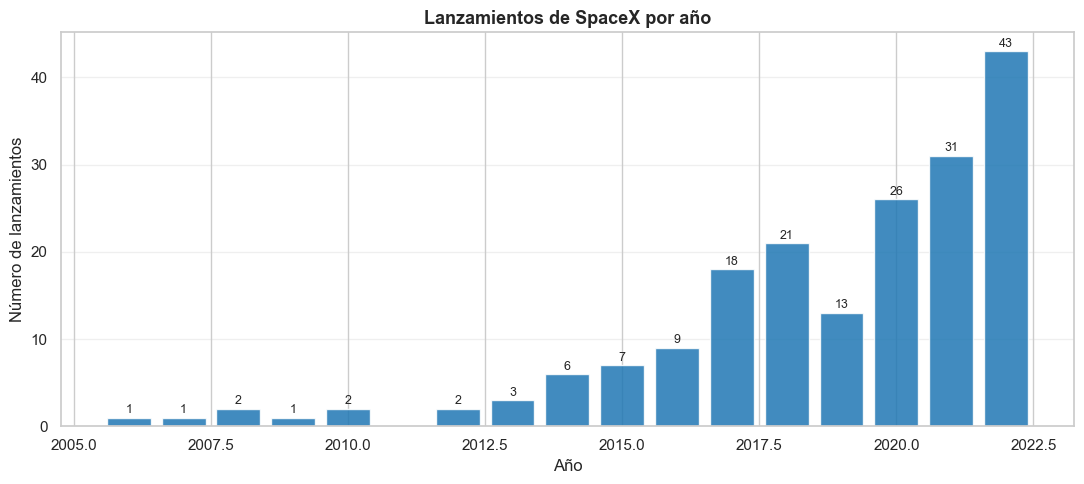

In [24]:


# groupby('year').size() cuenta filas por a?o.
# El resultado es una Series: ?ndice=a?o, valor=número de lanzamientos.
launches_por_anio = df.groupby('year').size()

# Creamos figura y eje expl?citamente para controlar el gráfico con orientaci?n a objetos.
# figsize=(11, 5) define ancho y alto en pulgadas.
fig, ax = plt.subplots(figsize=(11, 5))

# ax.bar crea un gráfico de barras.
# index son los años; values son los conteos.
# color define el color; alpha controla transparencia.
ax.bar(launches_por_anio.index, launches_por_anio.values, color='#1f77b4', alpha=0.85)

# Título con tamaño y peso para que se lea bien proyectado.
ax.set_title('Lanzamientos de SpaceX por año', fontsize=13, fontweight='bold')

# Etiquetas de ejes: siempre deben explicar unidades o dimensi?n.
ax.set_xlabel('Año')
ax.set_ylabel('Número de lanzamientos')

# Agregamos grilla horizontal sutil para facilitar comparaci?n de alturas.
ax.grid(axis='y', alpha=0.3)

# A?adimos el valor encima de cada barra para lectura directa.
for x, y in zip(launches_por_anio.index, launches_por_anio.values):
    # x es el a?o; y es la altura de la barra.
    # y + 0.5 sube la etiqueta un poco por encima de la barra.
    # ha='center' centra el texto horizontalmente.
    ax.text(x, y + 0.5, str(y), ha='center', fontsize=9)

# tight_layout ajusta m?rgenes para evitar que t?tulos/labels se corten.
plt.tight_layout()

# show renderiza el gr?fico en el notebook.
plt.show()

**Combinamos cantidad y calidad.**

Un año con muchos lanzamientos no necesariamente es mejor si la tasa de éxito cae. Esta visualización pone juntas dos métricas con escalas distintas: volumen y porcentaje de éxito. El beneficio es evitar conclusiones incompletas mirando solo una métrica.


### 5.2 Pregunta: Mejora la tasa de éxito con el tiempo?

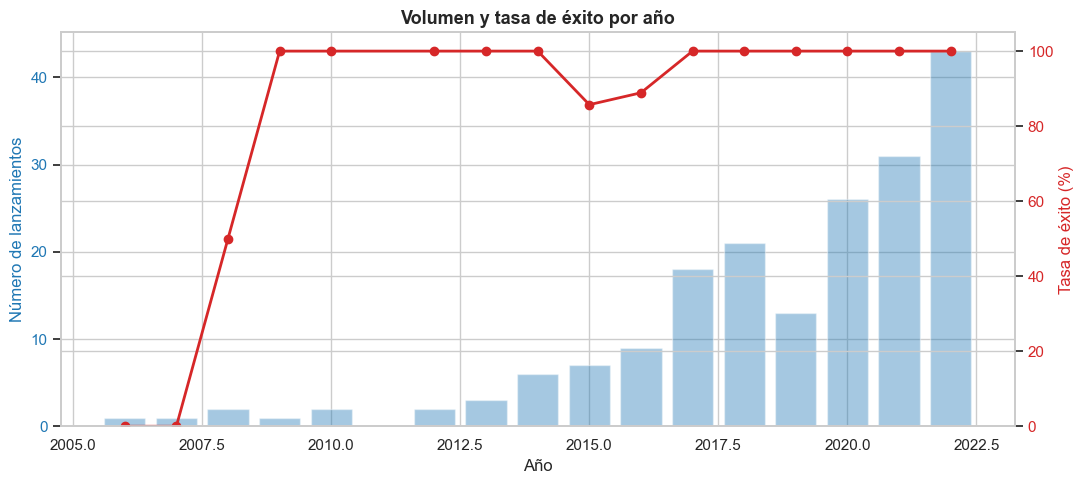

In [25]:
# Agrupamos por año y calculamos dos métricas sobre success.
# size cuenta lanzamientos; mean calcula proporción de True porque True=1 y False=0.
tasa_por_anio = df.groupby('year').agg(
    lanzamientos=('success', 'size'),
    tasa_exito=('success', 'mean')
).reset_index()

# reset_index convierte el ?ndice year de nuevo en columna normal.

# Creamos una figura con un eje principal.
fig, ax1 = plt.subplots(figsize=(11, 5))

# Color para barras de volumen.
color1 = '#1f77b4'

# Barras: número de lanzamientos por año en eje izquierdo.
# alpha=0.4 baja intensidad para que la línea del segundo eje destaque.
ax1.bar(tasa_por_anio['year'], tasa_por_anio['lanzamientos'],
        color=color1, alpha=0.4, label='Lanzamientos (eje izq)')

# Etiquetas y color del eje izquierdo.
ax1.set_xlabel('Año')
ax1.set_ylabel('Número de lanzamientos', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# twinx crea un segundo eje Y compartiendo el mismo eje X.
# Sirve cuando las escalas son distintas: conteo vs porcentaje.
ax2 = ax1.twinx()

# Color para la tasa de ?xito.
color2 = '#d62728'

# Línea: tasa de éxito anual en porcentaje.
# Multiplicamos por 100 porque mean devuelve 0-1.
# marker='o' marca cada año; linewidth=2 mejora visibilidad.
ax2.plot(tasa_por_anio['year'], tasa_por_anio['tasa_exito'] * 100,
         color=color2, marker='o', linewidth=2, label='Tasa de éxito (eje der)')

# Etiqueta y color del eje derecho.
ax2.set_ylabel('Tasa de éxito (%)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Limitamos el eje derecho a 0-105 para interpretar como porcentaje.
# 105 deja un pequeño margen visual arriba de 100.
ax2.set_ylim(0, 105)

# Título general del gráfico.
ax1.set_title('Volumen y tasa de éxito por año', fontsize=13, fontweight='bold')

# Ajuste de márgenes.
plt.tight_layout()

# Renderizado en notebook.
plt.show()

**Pasamos de tendencia temporal a comparación de estrategia.**

La reutilización de boosters es una decisión central del negocio de SpaceX. Esta celda compara resultados entre lanzamientos con y sin booster reutilizado. El beneficio es conectar una transformación tócnica del dataset con una pregunta analítica de negocio.


### 5.3 Pregunta: La reutilización de boosters afecta la tasa de éxito?

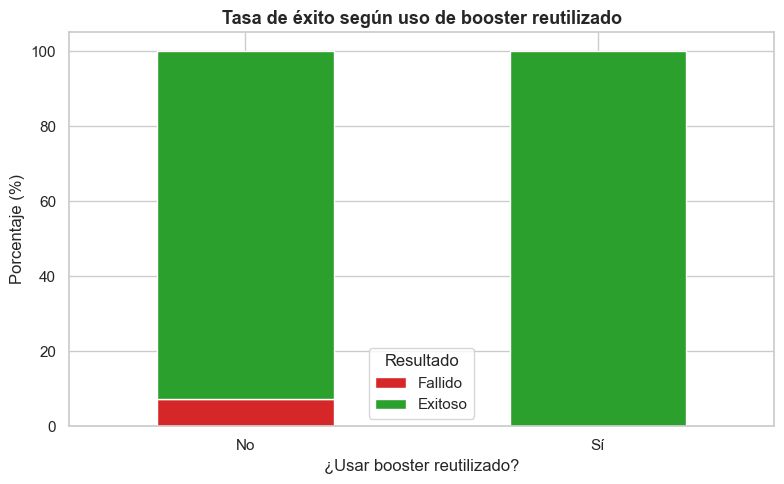


Tabla cruzada (porcentajes por fila):
success              False   True 
used_reused_booster               
False                 7.14   92.86
True                  0.00  100.00


In [26]:
# Esta es una pregunta de negocio real: la apuesta de SpaceX por reutilización.

# pd.crosstab crea una tabla cruzada entre used_reused_booster y success.
# normalize='index' convierte cada fila en proporciones que suman 1.
# Multiplicamos por 100 para expresarlo como porcentaje.
tabla = pd.crosstab(df['used_reused_booster'], df['success'], normalize='index') * 100

# Creamos figura y eje.
fig, ax = plt.subplots(figsize=(8, 5))

# Graficamos la tabla cruzada como barras apiladas.
# kind='bar' usa barras verticales; stacked=True apila fallido/exitoso por grupo.
# color define rojo para False/fallido y verde para True/exitoso.
tabla.plot(kind='bar', stacked=True, ax=ax, color=['#d62728', '#2ca02c'])

# Título y etiquetas.
ax.set_title('Tasa de éxito según uso de booster reutilizado', fontsize=13, fontweight='bold')
ax.set_xlabel('¿Usar booster reutilizado?')
ax.set_ylabel('Porcentaje (%)')

# La leyenda traduce False/True a etiquetas más humanas.
ax.legend(['Fallido', 'Exitoso'], title='Resultado')

# Cambiamos etiquetas del eje X para que no aparezcan False/True crudos.
# rotation=0 deja el texto horizontal.
ax.set_xticklabels(['No', 'Sí'], rotation=0)

# Ajuste de márgenes.
plt.tight_layout()

# Renderizado.
plt.show()

# También imprimimos la tabla exacta porque el gráfico comunica, pero la tabla cuantifica.
print('\nTabla cruzada (porcentajes por fila):')
print(tabla.round(2))

**Cerramos visualización con concentración operativa.**

Saber qué plataformas concentran m?s actividad ayuda a interpretar logística, infraestructura y sesgos del dataset. El gráfico horizontal facilita leer nombres largos y comparar rápidamente las plataformas más usadas.


### 5.4 Pregunta: Qué launchpads son los más activos?

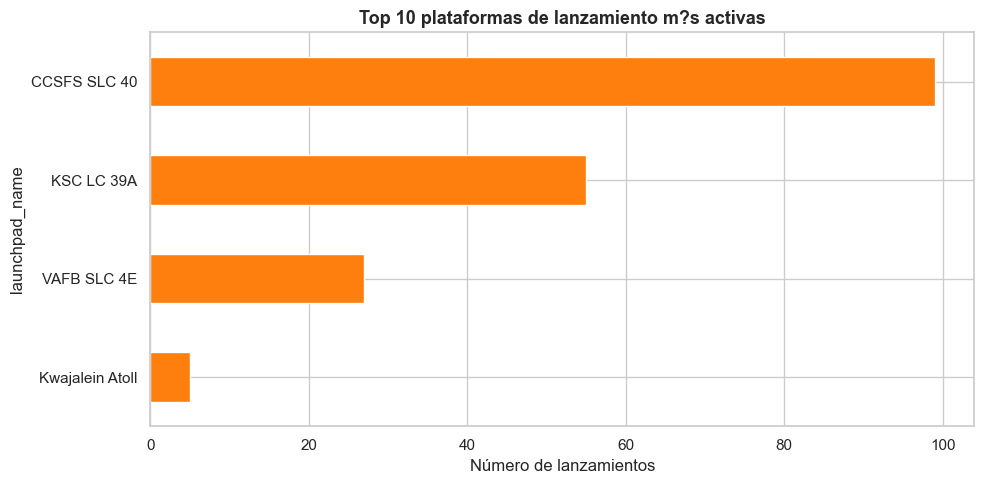

In [27]:
# value_counts() cuenta lanzamientos por plataforma.
# head(10) conserva las 10 plataformas más frecuentes.
top_pads = df['launchpad_name'].value_counts().head(10)

# Creamos figura y eje.
fig, ax = plt.subplots(figsize=(10, 5))

# kind='barh' crea barras horizontales, útiles para nombres largos.
top_pads.plot(kind='barh', ax=ax, color='#ff7f0e')

# Título y etiqueta de eje.
ax.set_title('Top 10 plataformas de lanzamiento m?s activas', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de lanzamientos')

# invert_yaxis pone la plataforma con más lanzamientos arriba.
ax.invert_yaxis()

# Ajuste de márgenes.
plt.tight_layout()

# Renderizado.
plt.show()

---
## 6. Cierre: checklist de calidad del dataset final

Antes de dar por terminado un pipeline, valida explícitamente. No asumas.

Nota: este `df` es un dataset analítico enriquecido para EDA. Si después quieres modelar, conviene crear una tabla `df_model` separada con columnas numéricas/booleanas limpias y sin listas u objetos anidados.

**Antes de terminar, validamos explícitamente.**

El cierre no busca descubrir algo nuevo, sino confirmar que el pipeline dejó un dataset coherente: filas esperadas, rango temporal claro, target sin nulos, IDs sin duplicados y tipos entendibles. Este hábito es clave antes de compartir un dataset, visualizar conclusiones o pasar a modelado.


In [28]:
# Separador visual para la salida del checklist final.
print('?' * 60)
print('CHECKLIST FINAL DEL DATASET')
print('?' * 60)

# Cantidad final de filas tras filtros y transformaciones.
print(f'Filas:                   {len(df)}')

# Cantidad final de columnas, incluyendo features y dummies.
print(f'Columnas:                {df.shape[1]}')

# Rango temporal final ya filtrado a lanzamientos ocurridos con success conocido.
# .date() muestra solo fecha, sin hora ni zona horaria.
print(f'Rango temporal:          {df["date_utc"].min().date()} ? {df["date_utc"].max().date()}')

# Validación de unicidad del identificador principal.
print(f'Duplicados por id:       {df["id"].duplicated().sum()}')

# Validación de que la variable target no tiene nulos tras limpieza.
print(f'Nulos en columna target: {df["success"].isna().sum()}')

# memory_usage(deep=True) estima memoria incluyendo objetos Python como strings/listas.
# Dividimos por 1024**2 para convertir bytes a MB.
print(f'Uso de memoria:          {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

# Línea en blanco para separar secciones de salida.
print()

# Resumen de tipos de datos: útil para saber cuánto falta si queremos modelar.
print('Tipos de columnas generadas:')
print(df.dtypes.value_counts())

????????????????????????????????????????????????????????????
CHECKLIST FINAL DEL DATASET
????????????????????????????????????????????????????????????
Filas:                   186
Columnas:                53
Rango temporal:          2006-03-24 ? 2022-10-05
Duplicados por id:       0
Nulos en columna target: 0
Uso de memoria:          0.37 MB

Tipos de columnas generadas:
str                    16
object                 11
bool                   10
int64                   6
float64                 5
int32                   3
datetime64[us, UTC]     2
Name: count, dtype: int64


## 📝 Ejercicios propuestos

1. **Fácil:** Calcula el coste acumulado de todos los lanzamientos exitosos vs fallidos usando `rocket_cost_per_launch`.
2. **Medio:** Construye una tabla que, para cada tipo de cohete, muestre: lanzamientos totales, tasa de éxito, tasa de reutilización y días promedio entre lanzamientos.
3. **Difícil:** Usa el endpoint `/payloads` para enriquecer el dataset con la masa total (kg) lanzada por misión. Los `payloads` dentro de `df_launches` son IDs — tendrás que resolverlos contra `df_payloads` y sumar `mass_kg` agrupando por lanzamiento. Ojo con los nulos en `mass_kg`: no todos los payloads tienen masa reportada.
4. **Bonus:** Ajusta un modelo de clasificación simple (logistic regression) que prediga `success` a partir de las features generadas. Evalúa con validación temporal (no random split: el tiempo importa).

In [32]:
df.columns

Index(['static_fire_date_utc', 'static_fire_date_unix', 'net', 'window', 'rocket', 'success', 'failures', 'details', 'crew', 'ships', 'capsules', 'payloads', 'launchpad', 'flight_number', 'name',
       'date_utc', 'date_unix', 'date_local', 'date_precision', 'upcoming', 'cores', 'auto_update', 'tbd', 'launch_library_id', 'id', 'fairings_reused', 'fairings_recovery_attempt',
       'fairings_recovered', 'fairings_ships', 'fairings', 'rocket_id', 'rocket_name', 'rocket_type', 'rocket_active', 'rocket_cost_per_launch', 'rocket_success_rate_pct', 'launchpad_id',
       'launchpad_name', 'launchpad_region', 'launchpad_locality', 'year', 'month', 'quarter', 'day_of_week', 'is_weekend', 'n_payloads', 'n_cores', 'used_reused_booster', 'all_landings_successful',
       'tasa_exito_historica', 'dias_desde_anterior', 'rocket_Falcon 9', 'rocket_Falcon Heavy'],
      dtype='str')

In [33]:
df.groupby('success')['rocket_cost_per_launch'].sum()

success
False     120100000
True     9083400000
Name: rocket_cost_per_launch, dtype: int64

In [34]:
df['date_utc'] = pd.to_datetime(df['date_utc'])

tabla = df.sort_values('date_utc').groupby('rocket_name').agg(
    lanzamientos=('success', 'count'),
    tasa_exito=('success', 'mean'),
    reutilizacion=('used_reused_booster', 'mean'),
    dias_promedio=('date_utc', lambda x: x.diff().dt.days.mean())
)

tabla

,lanzamientos,tasa_exito,reutilizacion,dias_promedio
rocket_name,,,,
Falcon 1,5,0.400000,0.000000,301.250000
Falcon 9,178,0.988764,0.640449,24.903955
Falcon Heavy,3,1.000000,0.666667,251.500000


In [35]:
# explotar lista de payloads
df_exp = df.explode('payloads')

# merge con df_payloads
df_merge = df_exp.merge(df_payloads, left_on='payloads', right_on='id', how='left')

# limpiar nulos
df_merge['mass_kg'] = df_merge['mass_kg'].fillna(0)

# masa total por lanzamiento
masa_total = df_merge.groupby('id_x')['mass_kg'].sum()

masa_total

id_x
5eb87cd9ffd86e000604b32a       20.0
5eb87cdaffd86e000604b32b        0.0
5eb87cdbffd86e000604b32c        0.0
5eb87cdbffd86e000604b32d      165.0
5eb87cdcffd86e000604b32e      200.0
                             ...   
62f3b5290f55c50e192a4e6d    13260.0
62f3b5330f55c50e192a4e6e    13440.0
62f3b53a0f55c50e192a4e6f    13260.0
63161329ffc78f3b8567070b    13260.0
63161339ffc78f3b8567070c    13260.0
Name: mass_kg, Length: 186, dtype: float64

In [37]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 37.5 MB/s  0:00:00 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [41]:
import sys
print (sys.executable)

/usr/local/bin/python3.14


In [42]:
import sys
!{sys.executable} -m pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 33.9 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [44]:


features = ['rocket_cost_per_launch', 'used_reused_booster', 'n_cores', 'n_payloads']

X = df[features].fillna(0)
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0
